# Aplicação de Machine Learning na Predição de Inadimplência e Apoio à Decisão de Crédito


**Objetivo Principal:** Construir um modelo preditivo que encontre a probabilidade de um cliente ser inadimplente.

**Segundo a regra de negócio:** Atraso de 5 ou mais dias no pagamento.

# 1. Preparação de Ambiente
Todas as versões utilizadas no ambiente, estão no arquivo 'requirements.txt'.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

import lightgbm as lgb

#sns.set_style('whitegrid')
#plt.rcParams['figure.figsize'] = (12, 6)
#plt.rcParams['font.size'] = 12

# 1. Define o estilo base como 'white' (fundo branco sem grades) conforme Tabela 8
sns.set_style("white")

# 2. Configurações globais para evitar Warnings e manter a norma (Tabela 8)
plt.rcParams['font.family'] = 'sans-serif'
# Adicionamos fontes similares como fallback para evitar o erro de 'Arial not found'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans', 'Bitstream Vera Sans', 'sans-serif']

plt.rcParams['font.size'] = 11            # Tamanho Arial 11 [1]
plt.rcParams['axes.labelcolor'] = 'black' # Texto sempre em preto [2]
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# 3. Configuração dos eixos (Linha sólida preta de 1,5 pt) [2]
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# 4. Desativação obrigatória de grades e títulos internos [2]
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.top'] = False    # Remove borda superior
plt.rcParams['axes.spines.right'] = False  # Remove borda direita

print("Configurações aplicadas com sucesso. Fallback de fontes ativado.")

Configurações aplicadas com sucesso. Fallback de fontes ativado.


## 1.2. Carregamento dos Dados

In [2]:

try:
    df_cadastral_raw = pd.read_csv(('base_cadastral.csv'), sep=';')
    df_info_raw = pd.read_csv(('base_info.csv'), sep=';')
    df_dev_raw = pd.read_csv(('base_pagamentos_desenvolvimento.csv'), sep=';')
    df_teste_raw = pd.read_csv(( 'base_pagamentos_teste.csv'), sep=';')
except:
    print("Erro ao ler os arquivos CSV. Verifique o caminho e o formato dos arquivos.")
    raise

# Criando cópias para pré-processamento
df_cadastral_proc = df_cadastral_raw.copy()
df_info_proc = df_info_raw.copy()
df_dev_proc = df_dev_raw.copy()
df_teste_proc = df_teste_raw.copy()


# 2. Análise Exploratória e Visualizações

O objetivo foi realizar uma exploração bem abrangente, com isso, poder identificar a estrutura de cada base, a presença de valores ausentes, a distribuição das variáveis-chave

e extrair os primeiros insights sobre o perfil dos clientes e o comportamento de pagamento, que nortearam as etapas seguintes de pré-processamento e engenharia de atributos.

## 2.1. Análise Inicial
Esta análise visa realizar um "raio-x" dos DataFrames, mostrando suas estruturas, tipos de dados e uma amostras dos valores reais.

Além da quantidade e porcentagem de dados ausentes em cada Feature.

In [3]:
#Análise do DataFrame: df_cadastral_raw
print("Análise do DataFrame: df_cadastral_raw:")
print("\nInformações Gerais:")
df_cadastral_raw.info()
print("\n Features atuais dos Dados:")
print(df_cadastral_raw.head())
print("\nContagem de Valores Nulos por Feature:")
print(df_cadastral_raw.isnull().sum())
print("\nPorcentagem de Valores Nulos por Coluna:")
print(((df_cadastral_raw.isnull().sum() / len(df_cadastral_raw)) * 100).round(2))

Análise do DataFrame: df_cadastral_raw:

Informações Gerais:
<class 'pandas.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID_CLIENTE           1315 non-null   int64
 1   DATA_CADASTRO        1315 non-null   str  
 2   DDD                  1078 non-null   str  
 3   FLAG_PF              66 non-null     str  
 4   SEGMENTO_INDUSTRIAL  1232 non-null   str  
 5   DOMINIO_EMAIL        1285 non-null   str  
 6   PORTE                1274 non-null   str  
 7   CEP_2_DIG            1315 non-null   str  
dtypes: int64(1), str(7)
memory usage: 82.3 KB

 Features atuais dos Dados:
            ID_CLIENTE DATA_CADASTRO DDD FLAG_PF SEGMENTO_INDUSTRIAL  \
0  1661240395903230676    2013-08-22  99     NaN            Serviços   
1  8274986328479596038    2017-01-25  31     NaN            Comércio   
2   345447888460137901    2000-08-15  75     NaN            Serviços   


In [4]:
#Análise do DataFrame: df_info_raw
print("Análise do DataFrame: df_info_raw:")
print("\nInformações Gerais:")
df_info_raw.info()
print("\n Features atuais dos Dados:")
print(df_info_raw.head())
print("\nContagem de Valores Nulos por Feature:")
print(df_info_raw.isnull().sum())
print("\nPorcentagem de Valores Nulos por Coluna:")
print(((df_info_raw.isnull().sum() / len(df_info_raw)) * 100).round(2))

Análise do DataFrame: df_info_raw:

Informações Gerais:
<class 'pandas.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  str    
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 762.7 KB

 Features atuais dos Dados:
            ID_CLIENTE SAFRA_REF  RENDA_MES_ANTERIOR  NO_FUNCIONARIOS
0  1661240395903230676   2018-09             16913.0              NaN
1  8274986328479596038   2018-09            106430.0            141.0
2   345447888460137901   2018-09            707439.0             99.0
3  1003144834589372198   2018-09            239659.0             96.0
4   324916756972236008   2018-09            203123.0            103.0

Contagem de Valores Nulos por Feature:
ID_C

In [5]:
#Análise do DataFrame: df_pagamentos_desenvolvimento
print("Análise do DataFrame: df_pagamentos_desenvolvimento:")
print("\nInformações Gerais:")
df_dev_raw.info()
print("\n Features atuais dos Dados:")
print(df_dev_raw.head())
print("\nContagem de Valores Nulos por Feature:")
print(df_dev_raw.isnull().sum())
print("\nPorcentagem de Valores Nulos por Coluna:")
print(((df_dev_raw.isnull().sum() / len(df_dev_raw)) * 100).round(2))

Análise do DataFrame: df_pagamentos_desenvolvimento:

Informações Gerais:
<class 'pandas.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  str    
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  str    
 3   DATA_PAGAMENTO          77414 non-null  str    
 4   DATA_VENCIMENTO         77414 non-null  str    
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 4.1 MB

 Features atuais dos Dados:
            ID_CLIENTE SAFRA_REF DATA_EMISSAO_DOCUMENTO DATA_PAGAMENTO  \
0  1661240395903230676   2018-08             2018-08-17     2018-09-06   
1  1661240395903230676   2018-08             2018-08-19     2018-09-11   
2  1661240395903230676   2018-08           

In [6]:
#Análise do DataFrame: df_pagamentos_teste
print("Análise do DataFrame: df_pagamentos_teste:")
print("\nInformações Gerais:")
df_teste_raw.info()
print("\n Features atuais dos Dados:")
print(df_teste_raw.head())
print("\nContagem de Valores Nulos por Feature:")
print(df_teste_raw.isnull().sum())
print("\nPorcentagem de Valores Nulos por Coluna:\n",((df_teste_raw.isnull().sum() / len(df_teste_raw)) * 100).round(2))


Análise do DataFrame: df_pagamentos_teste:

Informações Gerais:
<class 'pandas.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  str    
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  str    
 3   DATA_VENCIMENTO         12275 non-null  str    
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 575.5 KB

 Features atuais dos Dados:
            ID_CLIENTE SAFRA_REF DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
0  5058298901476893676   2021-07             2021-07-14      2021-08-04   
1   274692171162531764   2021-07             2021-07-08      2021-08-23   
2   274692171162531764   2021-07             2021-07-11      2021-08-25   
3   274692171162531764   2

## 2.2. Visualizações
Esta análise fornece insights dos DataFrames de maneira individual, para entendermos melhor sobre o negócio.


### 2.2.1 - Insights do DataFrame Cadastral

C:\Users\betim\AppData\Local\Temp\ipykernel_1476\4280247614.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='TIPO_CLIENTE', data=df_cadastral_raw, palette='viridis',


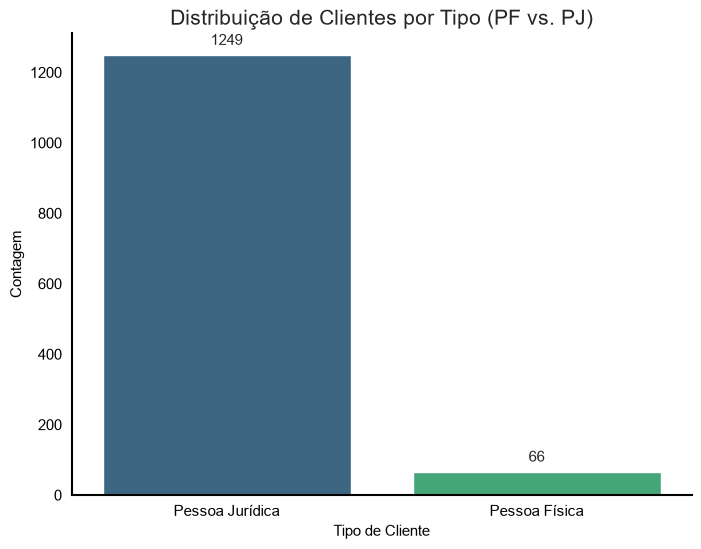

C:\Users\betim\AppData\Local\Temp\ipykernel_1476\4280247614.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='SEGMENTO_INDUSTRIAL', data=df_pj,


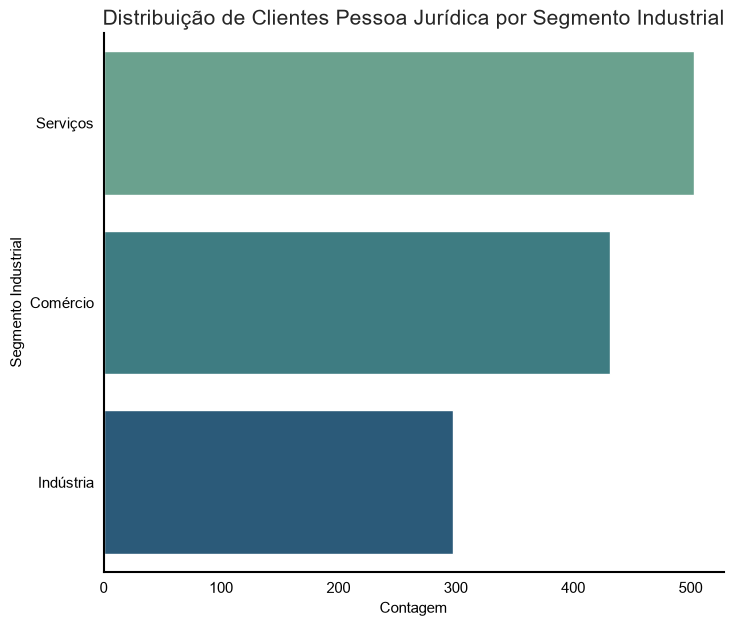

C:\Users\betim\AppData\Local\Temp\ipykernel_1476\4280247614.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='PORTE', data=df_pj, order=df_pj['PORTE'].value_counts().index, palette='magma')


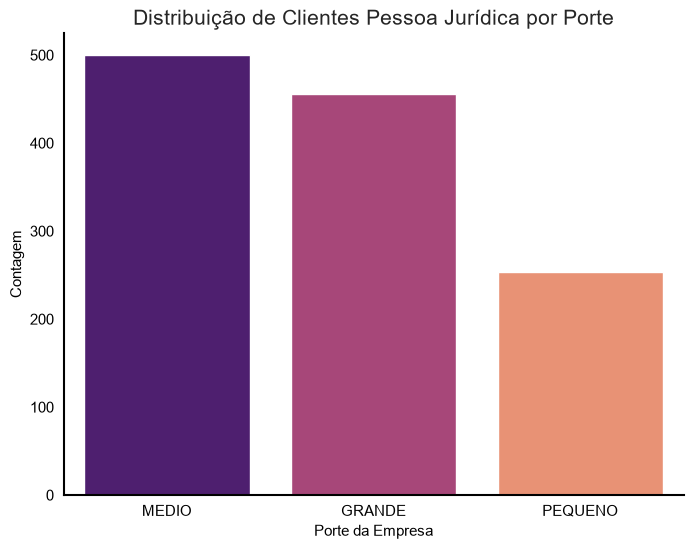

In [7]:
df_cadastral_raw.loc[df_cadastral_raw['FLAG_PF'] == 'X', 'TIPO_CLIENTE'] = 'Pessoa Física'
df_cadastral_raw.loc[df_cadastral_raw['FLAG_PF'] != 'X', 'TIPO_CLIENTE'] = 'Pessoa Jurídica'

# Plotando a distribuição de Tipo de Cliente (PF vs. PJ)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='TIPO_CLIENTE', data=df_cadastral_raw, palette='viridis',
                   order=df_cadastral_raw['TIPO_CLIENTE'].value_counts().index)
ax.set_title('Distribuição de Clientes por Tipo (PF vs. PJ)', fontsize=15)
ax.set_xlabel('Tipo de Cliente')
ax.set_ylabel('Contagem')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=5)
plt.show()

#------

# Plotando a distribuição de Tipo de Segmento (Industrial, Comércio, Serviços)
df_pj = df_cadastral_raw[df_cadastral_raw['TIPO_CLIENTE'] == 'Pessoa Jurídica'].copy()

plt.figure(figsize=(8, 7))
ax = sns.countplot(y='SEGMENTO_INDUSTRIAL', data=df_pj,
                   order=df_pj['SEGMENTO_INDUSTRIAL'].value_counts().index, palette='crest')
ax.set_title('Distribuição de Clientes Pessoa Jurídica por Segmento Industrial', fontsize=15)
ax.set_xlabel('Contagem')
ax.set_ylabel('Segmento Industrial')
plt.show()

# Plotando a distribuição de Porte das Empresas
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='PORTE', data=df_pj, order=df_pj['PORTE'].value_counts().index, palette='magma')
ax.set_title('Distribuição de Clientes Pessoa Jurídica por Porte', fontsize=15)
ax.set_xlabel('Porte da Empresa')
ax.set_ylabel('Contagem')
plt.show()

Principais Insights:
* A base de clientes é predominantemente composta por Pessoas Jurídicas.
* O segmento de "SERVICOS" é o mais representativo entre os clientes PJ.
* A maioria das empresas clientes é de porte Médio.


### 2.2.2 - Insights do DataFrame Info

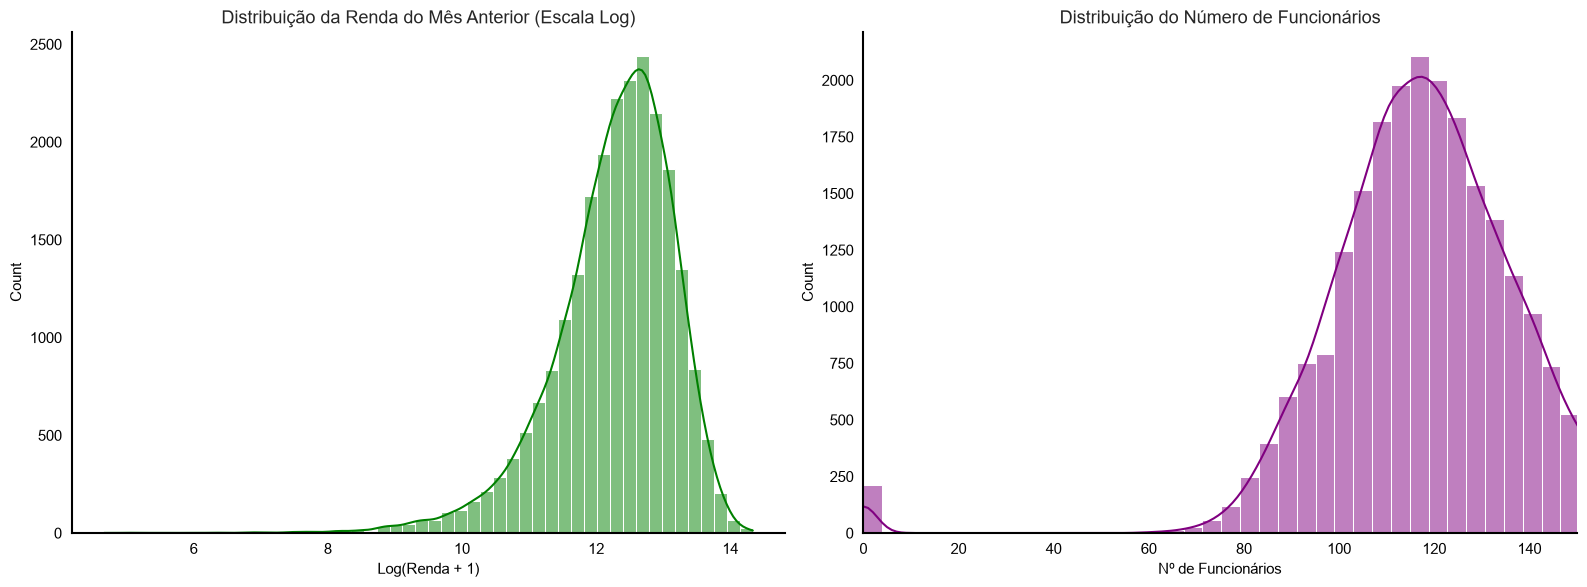

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Usando log para visualizar melhor a distribuição da Renda
sns.histplot(np.log1p(df_info_raw['RENDA_MES_ANTERIOR'].dropna()), bins=50, kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribuição da Renda do Mês Anterior (Escala Log)')
axes[0].set_xlabel('Log(Renda + 1)')

sns.histplot(df_info_raw['NO_FUNCIONARIOS'].dropna(), bins=50, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribuição do Número de Funcionários')
axes[1].set_xlabel('Nº de Funcionários')

axes[1].set_xlim(0, df_info_raw['NO_FUNCIONARIOS'].quantile(0.95))


plt.tight_layout()
plt.show()

Principais Insights:
* A distribuição é extremamente assimétrica, com a vasta maioria dos valores concentrada próxima de zero.
* A distribuição é multimodal, apresentando vários picos distintos.

### 2.2.3 - Insights do DataFrame Pagamentos Desenvolvidos

C:\Users\betim\AppData\Local\Temp\ipykernel_1476\2431327331.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='INADIMPLENTE', data=df_dev_raw, palette='Set1')
C:\Users\betim\AppData\Local\Temp\ipykernel_1476\2431327331.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])


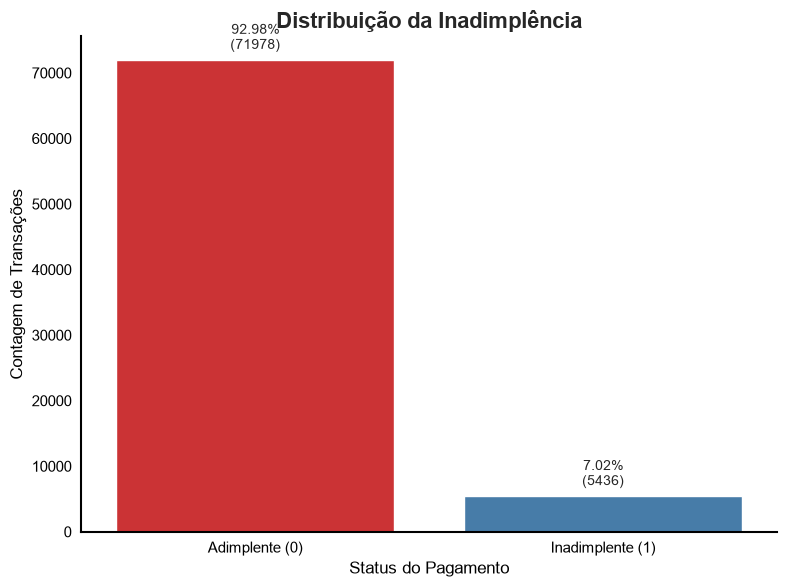

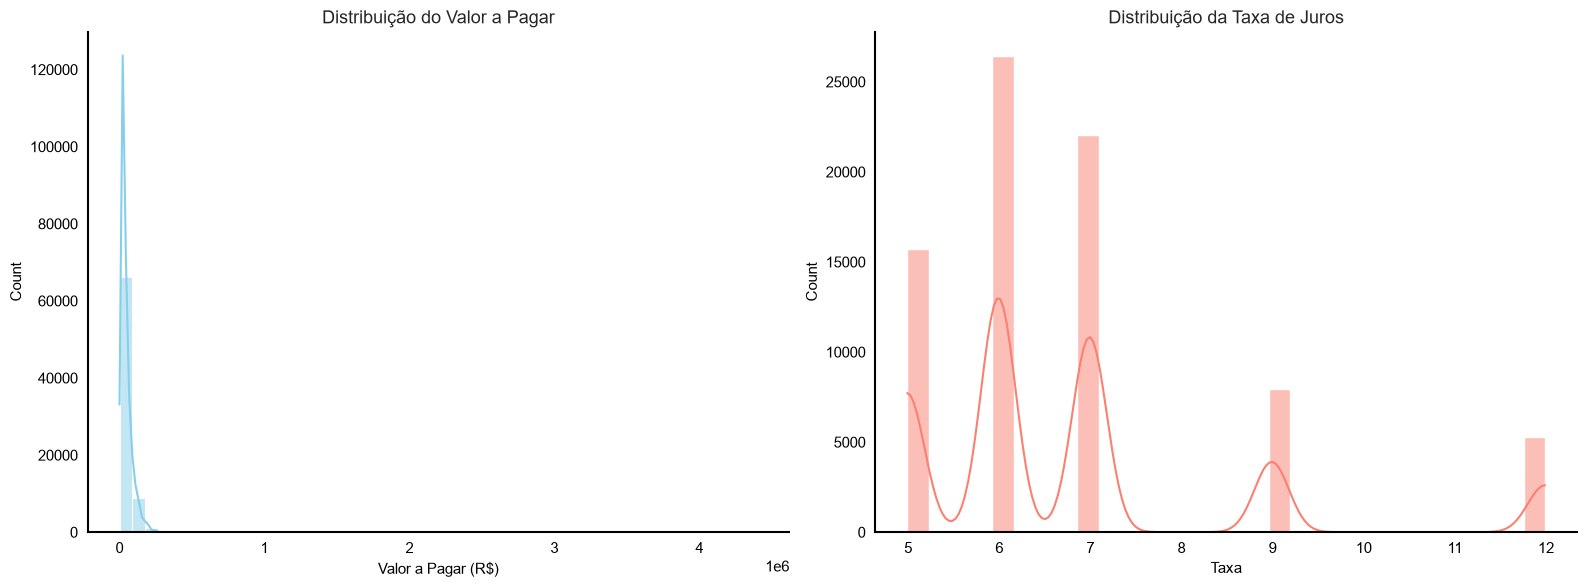

C:\Users\betim\AppData\Local\Temp\ipykernel_1476\2431327331.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='INADIMPLENTE', y='VALOR_A_PAGAR', data=df_dev_raw, palette='Set1')


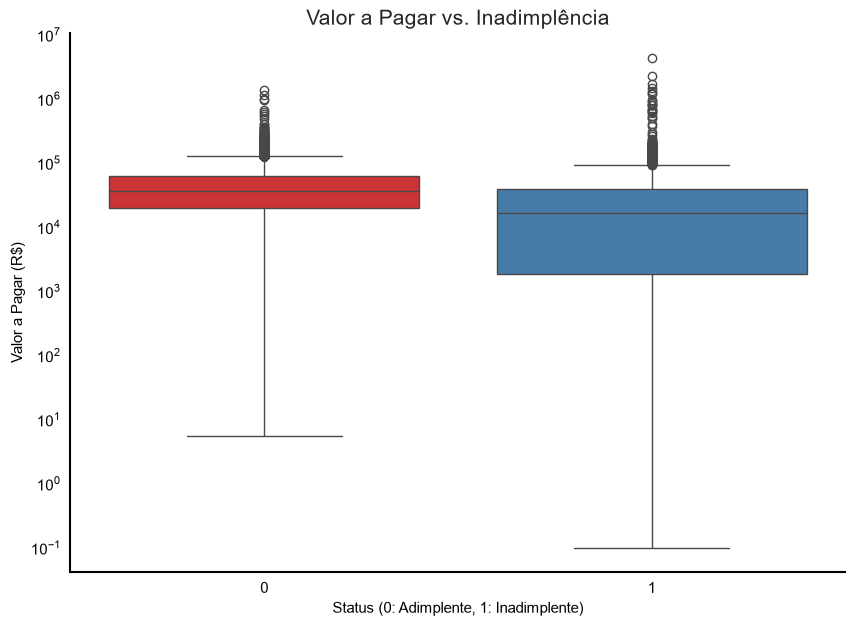

In [9]:
# Alterando temporariamente o tipo de dado das colunas de data para datetime, criando a Target
data_pagamento_temp = pd.to_datetime(df_dev_raw['DATA_PAGAMENTO'])
data_vencimento_temp = pd.to_datetime(df_dev_raw['DATA_VENCIMENTO'])

df_dev_raw['dias_atraso'] = (data_pagamento_temp - data_vencimento_temp).dt.days
df_dev_raw['INADIMPLENTE'] = (df_dev_raw['dias_atraso'] >= 5).astype(int)


# Plotando a distribuição da Inadimplência (Target)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='INADIMPLENTE', data=df_dev_raw, palette='Set1')

ax.set_title('Distribuição da Inadimplência', fontsize=16, weight='bold')
ax.set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])
ax.set_xlabel('Status do Pagamento', fontsize=12)
ax.set_ylabel('Contagem de Transações', fontsize=12)

total = len(df_dev_raw)
for container in ax.containers:
    labels = [f'{h / total:.2%}\n({h:.0f})' for h in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=10, padding=5)

plt.tight_layout()
plt.show()


# Plotando a distribuição do VALOR_A_PAGAR e TAXA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma do VALOR_A_PAGAR
sns.histplot(df_dev_raw['VALOR_A_PAGAR'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição do Valor a Pagar')
axes[0].set_xlabel('Valor a Pagar (R$)')

# Histograma da TAXA
sns.histplot(df_dev_raw['TAXA'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição da Taxa de Juros')
axes[1].set_xlabel('Taxa')

plt.tight_layout()
plt.show()


# Boxplot do VALOR_A_PAGAR por INADIMPLENTE
plt.figure(figsize=(10, 7))
sns.boxplot(x='INADIMPLENTE', y='VALOR_A_PAGAR', data=df_dev_raw, palette='Set1')
plt.title('Valor a Pagar vs. Inadimplência', fontsize=15)
plt.xlabel('Status (0: Adimplente, 1: Inadimplente)')
plt.ylabel('Valor a Pagar (R$)')

# Usando escala de log para melhor visualização devido aos outliers
plt.yscale('log')
plt.show()




Principais Insights:
* Desbalanceamento da Target (92.98% vs. 7.02%)
* Presença de muitos outliers
* O risco de inadimplência é mais prevalente entre transações de menor montante.

### 2.2.3. Insights do DataFrame Pagamentos Teste

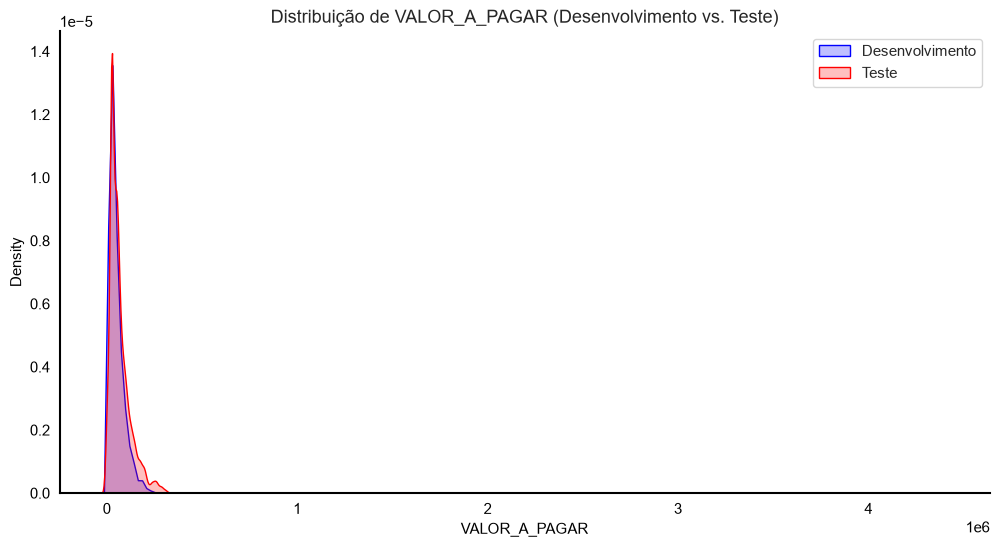

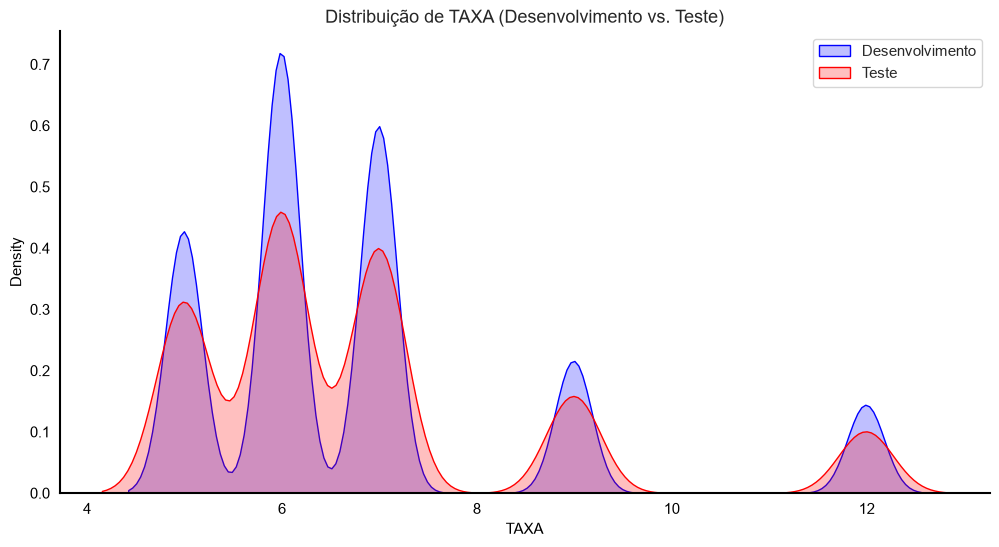

In [10]:
#plotando a distribuição de VALOR_A_PAGAR e TAXA entre Desenvolvimento e Teste

plt.figure(figsize=(12, 6))
sns.kdeplot(df_dev_raw['VALOR_A_PAGAR'].dropna(), label='Desenvolvimento', fill=True, color='blue')
sns.kdeplot(df_teste_raw['VALOR_A_PAGAR'].dropna(), label='Teste', fill=True, color='red')
plt.title('Distribuição de VALOR_A_PAGAR (Desenvolvimento vs. Teste)')
plt.legend()
plt.show()

#plotando a distribuição de TAXA entre Desenvolvimento e Teste
plt.figure(figsize=(12, 6))
sns.kdeplot(df_dev_raw['TAXA'].dropna(), label='Desenvolvimento', fill=True, color='blue')
sns.kdeplot(df_teste_raw['TAXA'].dropna(), label='Teste', fill=True, color='red')
plt.title('Distribuição de TAXA (Desenvolvimento vs. Teste)')
plt.legend()
plt.show()

Principais Insights:
* VALOR_A_PAGAR e TAXA são consistentes e semelhantes entre os conjuntos de desenvolvimento e teste.

# 3. Pré-Processamento dos Dados
Foi optado por realizar o pré-processamento em cada base de dados individualmente antes da junção para garantir maior integridade e precisão da análise.

Isto evita que haja duplicação de linhas, inerente ao processo de merge, distorça o cálculo de estatísticas como medianas e modas, que foram utilizadas para a imputação de valores ausentes.

 Além disso, essa estratégia promove um código mais organizado e modular

In [11]:
# Tratamento do DataFrame df_cadastral_proc: Limpeza, tratar nulos e Tipagem.

for col in ['DDD', 'DOMINIO_EMAIL', 'SEGMENTO_INDUSTRIAL', 'PORTE']:
    moda_valor = df_cadastral_proc[col].mode()[0]
    df_cadastral_proc[col] = df_cadastral_proc[col].fillna(moda_valor)

df_cadastral_proc['DATA_CADASTRO'] = pd.to_datetime(df_cadastral_proc['DATA_CADASTRO'])

df_cadastral_proc['FLAG_PF'] = df_cadastral_proc['FLAG_PF'].fillna('PJ')
df_cadastral_proc['FLAG_PF'] = df_cadastral_proc['FLAG_PF'].astype('category')

df_cadastral_proc['SEGMENTO_INDUSTRIAL'] = df_cadastral_proc['SEGMENTO_INDUSTRIAL'].astype('category')
df_cadastral_proc['PORTE'] = df_cadastral_proc['PORTE'].astype('category')

df_cadastral_proc = df_cadastral_proc.drop_duplicates(keep='first')

In [12]:
# Tratamento do DataFrame df_info_proc: Limpeza, tratar nulos e Tipagem.

df_info_proc['SAFRA_REF'] = pd.to_datetime(df_info_proc['SAFRA_REF'])

mediana_renda_info = df_info_proc['RENDA_MES_ANTERIOR'].median()
df_info_proc['RENDA_MES_ANTERIOR'] = df_info_proc['RENDA_MES_ANTERIOR'].fillna(mediana_renda_info)

mediana_func_info = df_info_proc['NO_FUNCIONARIOS'].median()
df_info_proc['NO_FUNCIONARIOS'] = df_info_proc['NO_FUNCIONARIOS'].fillna(mediana_func_info)
df_info_proc['NO_FUNCIONARIOS'] = df_info_proc['NO_FUNCIONARIOS'].round().astype('Int64')

df_info_proc = df_info_proc.drop_duplicates(keep='first')

In [13]:
# Tratamento do DataFrame df_dev_proc: Limpeza, tratar nulos e Tipagem.

date_cols = ['SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']
for col in date_cols:
    df_dev_proc[col] = pd.to_datetime(df_dev_proc[col])

mediana_valor_a_pagar_dev = df_dev_proc['VALOR_A_PAGAR'].median()
df_dev_proc['VALOR_A_PAGAR'] = df_dev_proc['VALOR_A_PAGAR'].fillna(mediana_valor_a_pagar_dev)

df_dev_proc['DIAS_ATRASO'] = (df_dev_proc['DATA_PAGAMENTO'] - df_dev_proc['DATA_VENCIMENTO']).dt.days

df_dev_proc['DIAS_EMISSAO_VENCIMENTO'] = (df_dev_proc['DATA_VENCIMENTO'] - df_dev_proc['DATA_EMISSAO_DOCUMENTO']).dt.days

df_dev_proc = df_dev_proc.drop_duplicates(keep='first')

In [14]:
# Tratamento do DataFrame df_teste_proc: Limpeza, tratar nulos e Tipagem.

date_cols = ['SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO',  'DATA_VENCIMENTO']
for col in date_cols:
    df_teste_proc[col] = pd.to_datetime(df_teste_proc[col])

mediana_valor_a_pagar_teste = df_teste_proc['VALOR_A_PAGAR'].median()
df_teste_proc['VALOR_A_PAGAR'] = df_teste_proc['VALOR_A_PAGAR'].fillna(mediana_valor_a_pagar_teste)

df_teste_proc['DIAS_EMISSAO_VENCIMENTO'] = (df_teste_proc['DATA_VENCIMENTO'] - df_teste_proc['DATA_EMISSAO_DOCUMENTO']).dt.days

df_teste_proc = df_teste_proc.drop_duplicates(keep='first')

# 4. União das Bases
Agrupando os DataFrames processados em um Dataframe final, tanto do Desenvolvimento, quanto do Teste.

In [15]:
# Merge dos pagamentos de DESENVOLVIMENTO com os dados cadastrais
df_dev_merged = pd.merge(
    df_dev_proc,
    df_cadastral_proc,
    on='ID_CLIENTE',
    how='left'
)

# Merge do resultado com as informações mensais
df_dev_final = pd.merge(
    df_dev_merged,
    df_info_proc,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

# Tratamento dos Nulos Pós-Merge (Desenvolvimento)
mediana_renda_pos_merge = df_dev_final['RENDA_MES_ANTERIOR'].median()
mediana_func_pos_merge = df_dev_final['NO_FUNCIONARIOS'].median()

df_dev_final['RENDA_MES_ANTERIOR'] = df_dev_final['RENDA_MES_ANTERIOR'].fillna(mediana_renda_pos_merge)
df_dev_final['NO_FUNCIONARIOS'] = df_dev_final['NO_FUNCIONARIOS'].fillna(mediana_func_pos_merge)

In [16]:
# Merge dos pagamentos de TESTE com os dados cadastrais
df_teste_merged = pd.merge(
    df_teste_proc,
    df_cadastral_proc,
    on='ID_CLIENTE',
    how='left'
)

# Merge com as informações mensais
df_teste_final = pd.merge(
    df_teste_merged,
    df_info_proc,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

df_teste_final['RENDA_MES_ANTERIOR'] = df_teste_final['RENDA_MES_ANTERIOR'].fillna(mediana_renda_pos_merge)
df_teste_final['NO_FUNCIONARIOS'] = df_teste_final['NO_FUNCIONARIOS'].fillna(mediana_func_pos_merge)

# 5. Feature Engineering

## 5.1. Criação da Variável Target (INADIMPLENTE)

In [17]:
df_dev_final['DIAS_ATRASO'] = (df_dev_final['DATA_PAGAMENTO'] - df_dev_final['DATA_VENCIMENTO']).dt.days
df_dev_final['INADIMPLENTE'] = (df_dev_final['DIAS_ATRASO'] >= 5).astype(int)

## 5.2. Criação de Features Preditivas

### 5.2.1. Features de Tempo
Extrair padrões de comportamento relacionados ao calendário para entender quando o risco de inadimplência aumenta.


In [18]:
def criar_features_de_tempo(df):
    df_copy = df.copy()

    # Features da data de vencimento, capturam padrões de pagamento sazonais, como o comportamento dos clientes no fim do mês ou perto de fins de semana.
    df_copy['VENC_DIA_DA_SEMANA'] = df_copy['DATA_VENCIMENTO'].dt.dayofweek
    df_copy['VENC_DIA_DO_MES'] = df_copy['DATA_VENCIMENTO'].dt.day
    df_copy['VENC_MES'] = df_copy['DATA_VENCIMENTO'].dt.month

    # Tempo de relacionamento do cliente em dias (até a emissão do documento). Mede a lealdade do cliente ao longo do tempo.
    df_copy['TEMPO_DE_CLIENTE_DIAS'] = (df_copy['DATA_EMISSAO_DOCUMENTO'] - df_copy['DATA_CADASTRO']).dt.days

    return df_copy


df_dev_featured = criar_features_de_tempo(df_dev_final)
df_teste_featured = criar_features_de_tempo(df_teste_final)


### 5.2.2. Features de Histórico do Cliente
Resumir o comportamento de pagamento passado do cliente para prever seu comportamento futuro.


In [19]:
# O DataFrame utilizado para criar as features de histórico é o df_dev_final, pois é o único que contém histórico de pagamento.
df_dev_final['DIAS_ATRASO'] = (df_dev_final['DATA_PAGAMENTO'] - df_dev_final['DATA_VENCIMENTO']).dt.days
df_dev_final['INADIMPLENTE'] = (df_dev_final['DIAS_ATRASO'] >= 5).astype(int)

# Ordenar para uso do .shift()
df_historico = df_dev_final[['ID_CLIENTE', 'SAFRA_REF', 'DIAS_ATRASO', 'INADIMPLENTE', 'VALOR_A_PAGAR']].sort_values(by=['ID_CLIENTE', 'SAFRA_REF'])

grouped = df_historico.groupby('ID_CLIENTE')

# Foi usado expanding() para criar uma janela que cresce com o tempo
# E shift(1) para garantir que estamos usando apenas dados do passado


df_historico['HIST_MEDIA_DIAS_ATRASO'] = grouped['DIAS_ATRASO'].transform(lambda x: x.shift(1).expanding().mean()).fillna(0)
df_historico['HIST_MAX_DIAS_ATRASO'] = grouped['DIAS_ATRASO'].transform(lambda x: x.shift(1).expanding().max()).fillna(0)
df_historico['HIST_TOTAL_INADIMPLENCIAS'] = grouped['INADIMPLENTE'].transform(lambda x: x.shift(1).expanding().sum()).fillna(0)
df_historico['HIST_TAXA_INADIMPLENCIA'] = (grouped['INADIMPLENTE'].transform(lambda x: x.shift(1).expanding().mean())*100).fillna(0)
df_historico['HIST_TOTAL_TRANSACOES'] = grouped.cumcount()

features_hist = [
    'ID_CLIENTE', 'SAFRA_REF', 'HIST_MEDIA_DIAS_ATRASO', 'HIST_MAX_DIAS_ATRASO',
    'HIST_TOTAL_INADIMPLENCIAS', 'HIST_TAXA_INADIMPLENCIA', 'HIST_TOTAL_TRANSACOES'
]

df_dev_final = pd.merge(df_dev_featured, df_historico[features_hist], on=['ID_CLIENTE', 'SAFRA_REF'], how='left')
df_teste_final = pd.merge(df_teste_featured, df_historico[features_hist], on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

# Clientes novos no teste podem não ter histórico, nesse caso foram preenchidos com 0
colunas_hist_para_preencher = [col for col in features_hist if col not in ['ID_CLIENTE', 'SAFRA_REF']]
df_teste_final[colunas_hist_para_preencher] = df_teste_final[colunas_hist_para_preencher].fillna(0)

print(df_dev_final[['ID_CLIENTE', 'SAFRA_REF'] + colunas_hist_para_preencher].head())
df_dev_final.columns.tolist()

            ID_CLIENTE  SAFRA_REF  HIST_MEDIA_DIAS_ATRASO  \
0  1661240395903230676 2018-08-01                0.000000   
1  1661240395903230676 2018-08-01                0.000000   
2  1661240395903230676 2018-08-01                0.500000   
3  1661240395903230676 2018-08-01                0.666667   
4  1661240395903230676 2018-08-01                2.000000   

   HIST_MAX_DIAS_ATRASO  HIST_TOTAL_INADIMPLENCIAS  HIST_TAXA_INADIMPLENCIA  \
0                   0.0                        0.0                      0.0   
1                   0.0                        0.0                      0.0   
2                   1.0                        0.0                      0.0   
3                   1.0                        0.0                      0.0   
4                   6.0                        1.0                     25.0   

   HIST_TOTAL_TRANSACOES  
0                      0  
1                      1  
2                      2  
3                      3  
4                      

['ID_CLIENTE',
 'SAFRA_REF',
 'DATA_EMISSAO_DOCUMENTO',
 'DATA_PAGAMENTO',
 'DATA_VENCIMENTO',
 'VALOR_A_PAGAR',
 'TAXA',
 'DIAS_ATRASO',
 'DIAS_EMISSAO_VENCIMENTO',
 'DATA_CADASTRO',
 'DDD',
 'FLAG_PF',
 'SEGMENTO_INDUSTRIAL',
 'DOMINIO_EMAIL',
 'PORTE',
 'CEP_2_DIG',
 'RENDA_MES_ANTERIOR',
 'NO_FUNCIONARIOS',
 'INADIMPLENTE',
 'VENC_DIA_DA_SEMANA',
 'VENC_DIA_DO_MES',
 'VENC_MES',
 'TEMPO_DE_CLIENTE_DIAS',
 'HIST_MEDIA_DIAS_ATRASO',
 'HIST_MAX_DIAS_ATRASO',
 'HIST_TOTAL_INADIMPLENCIAS',
 'HIST_TAXA_INADIMPLENCIA',
 'HIST_TOTAL_TRANSACOES']

### 5.2.3. Verificação da Qualidade das Features


Verificar a consistência e o poder preditivo das novas features antes de avançar para a modelagem.


In [20]:
# Verifcação de sanidade das novas features
colunas_para_verificar = [
    'TEMPO_DE_CLIENTE_DIAS', 'HIST_MEDIA_DIAS_ATRASO', 'HIST_TOTAL_INADIMPLENCIAS',
    'HIST_TAXA_INADIMPLENCIA'
]

print("Verificação de sanidade das novas features:")
print(df_dev_final[colunas_para_verificar].describe())

Verificação de sanidade das novas features:
       TEMPO_DE_CLIENTE_DIAS  HIST_MEDIA_DIAS_ATRASO  \
count          593591.000000           593591.000000   
mean             3952.569377                0.165065   
std              2321.288861                8.831769   
min               -13.000000             -252.800000   
25%              2037.000000               -0.080000   
50%              3292.000000                0.013514   
75%              6762.000000                0.600000   
max              7624.000000              458.000000   

       HIST_TOTAL_INADIMPLENCIAS  HIST_TAXA_INADIMPLENCIA  
count              593591.000000            593591.000000  
mean                   16.719494                 7.716959  
std                    42.264937                15.730618  
min                     0.000000                 0.000000  
25%                     0.000000                 0.000000  
50%                     1.000000                 0.568182  
75%                     9.00000

C:\Users\betim\AppData\Local\Temp\ipykernel_1476\3377196320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='INADIMPLENTE', y='HIST_TAXA_INADIMPLENCIA', data=df_dev_final, palette='viridis')


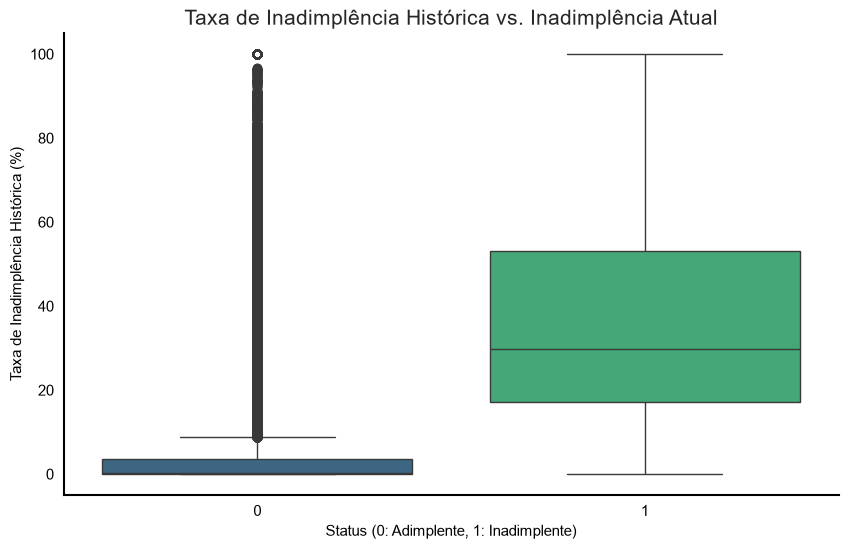

In [21]:
# Visualiznar a distribuição da taxa de inadimplência histórica para cada classe
plt.figure(figsize=(10, 6))
sns.boxplot(x='INADIMPLENTE', y='HIST_TAXA_INADIMPLENCIA', data=df_dev_final, palette='viridis')
plt.title('Taxa de Inadimplência Histórica vs. Inadimplência Atual', fontsize=15)
plt.xlabel('Status (0: Adimplente, 1: Inadimplente)')
plt.ylabel('Taxa de Inadimplência Histórica (%)')
plt.show()

# 6. Preparação dos Dados para o Modelo

## 6.1. Seleção das Features


In [22]:
target = 'INADIMPLENTE'

features_para_modelo = [
    # Features da base cadastral
    'FLAG_PF', 'SEGMENTO_INDUSTRIAL', 'PORTE',
    # Features da base info
    'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
    # Features da base de pagamentos
    'VALOR_A_PAGAR', 'TAXA', 'DIAS_EMISSAO_VENCIMENTO',
    # Features de tempo
    'VENC_DIA_DA_SEMANA', 'VENC_DIA_DO_MES', 'VENC_MES', 'TEMPO_DE_CLIENTE_DIAS',
    # Features de histórico
    'HIST_MEDIA_DIAS_ATRASO', 'HIST_MAX_DIAS_ATRASO', 'HIST_TOTAL_INADIMPLENCIAS',
    'HIST_TAXA_INADIMPLENCIA', 'HIST_TOTAL_TRANSACOES'
]

X = df_dev_final[features_para_modelo]
y = df_dev_final[target]

X_teste_final = df_teste_final[features_para_modelo]

## 6.2. Encoding de variáveis categóricas


In [23]:
# Codificação de variáveis categóricas, transformando-as em variáveis dummy para o modelo.

X_encoded = pd.get_dummies(X, drop_first=True)
X_teste_final_encoded = pd.get_dummies(X_teste_final, drop_first=True)


train_cols = X_encoded.columns
test_cols = X_teste_final_encoded.columns

X_teste_final_encoded = X_teste_final_encoded.reindex(
    columns=X_encoded.columns, fill_value=0
)

X_teste_final_encoded = X_teste_final_encoded[train_cols]


## 6.3. Divisão Treino/Validação (Time-Based Split)
Foi utilizado divisão temporal, garantindo que os dados de treinamento sejam cronologicamente anteriores aos dados de teste.


In [24]:
# Utilização dos 2 últimos meses de dados para validação, simulando um ambiente real.

safra_ref_dev = df_dev_final['SAFRA_REF']

data_de_corte = safra_ref_dev.max() - pd.DateOffset(months=2)

print(f"Dados de treino serão até a data: {data_de_corte.date()}")
print(f"Dados de validação serão após a data: {data_de_corte.date()}")

idx_treino = safra_ref_dev[safra_ref_dev < data_de_corte].index
idx_validacao = safra_ref_dev[safra_ref_dev >= data_de_corte].index

X_treino, X_validacao = X_encoded.loc[idx_treino], X_encoded.loc[idx_validacao]
y_treino, y_validacao = y.loc[idx_treino], y.loc[idx_validacao]

print(f"\nTamanho do conjunto de Treino: {X_treino.shape[0]} amostras")
print(f"Tamanho do conjunto de Validação: {X_validacao.shape[0]} amostras")

Dados de treino serão até a data: 2021-04-01
Dados de validação serão após a data: 2021-04-01

Tamanho do conjunto de Treino: 538791 amostras
Tamanho do conjunto de Validação: 54800 amostras


# 7. Escolha e Treinamento do Modelo
Foi escolhido o LightGBM para este problema de classificação devido à sua alta performance preditiva, eficiência e escalabilidade.

O algoritmo é ideal para dados tabulares e lida eficazmente com dados desbalanceados usando scale_pos_weight, simplificando a solução.

Confirmando um AUC de 0.97, sendo o melhor modelo segundo Benchmark realizado no fim do projeto.

## 7.1. LightGBM

In [25]:
#scale_pos_weight
contagem_classes = y_treino.value_counts()
negativos = contagem_classes[0]
positivos = contagem_classes[1]

escala = negativos / positivos
print(f"\nEscala de pesos para a classe positiva: {escala:.2f} (Negativos: {negativos}, Positivos: {positivos})")

lgbm_model = lgb.LGBMClassifier(objective='binary',
                                metric='auc',
                                scale_pos_weight=escala,
                                random_state=42,
                                n_estimators=1000)


lgbm_model.fit(X_treino, y_treino,
               eval_set=[(X_validacao, y_validacao)],
               eval_metric='auc',
               callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)])



Escala de pesos para a classe positiva: 7.86 (Negativos: 477981, Positivos: 60810)


c:\Users\betim\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 60810, number of negative: 477981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2272
[LightGBM] [Info] Number of data points in the train set: 538791, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112864 -> initscore=-2.061817
[LightGBM] [Info] Start training from score -2.061817
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[42]	valid_0's auc: 0.972061


,n_estimators,1000
,objective,'binary'
,random_state,42
,metric,'auc'
,scale_pos_weight,np.float64(7.860236803157376)
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,subsample_for_bin,200000
,class_weight,None


## 7.2 Avaliação de Performance do Modelo


AUC na Validação: 0.9721


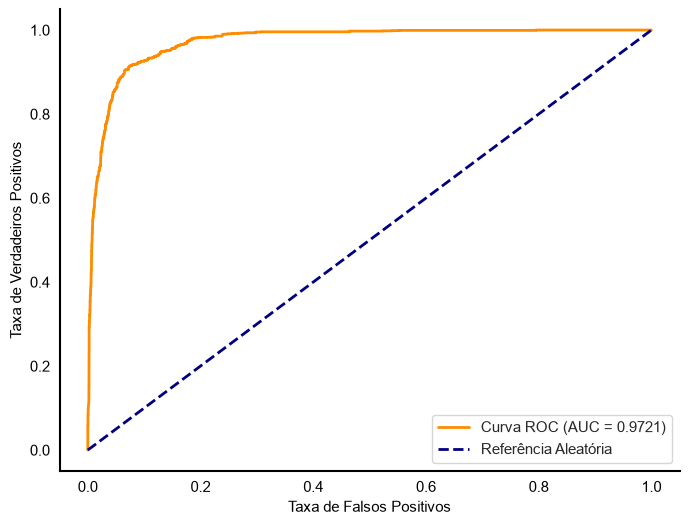

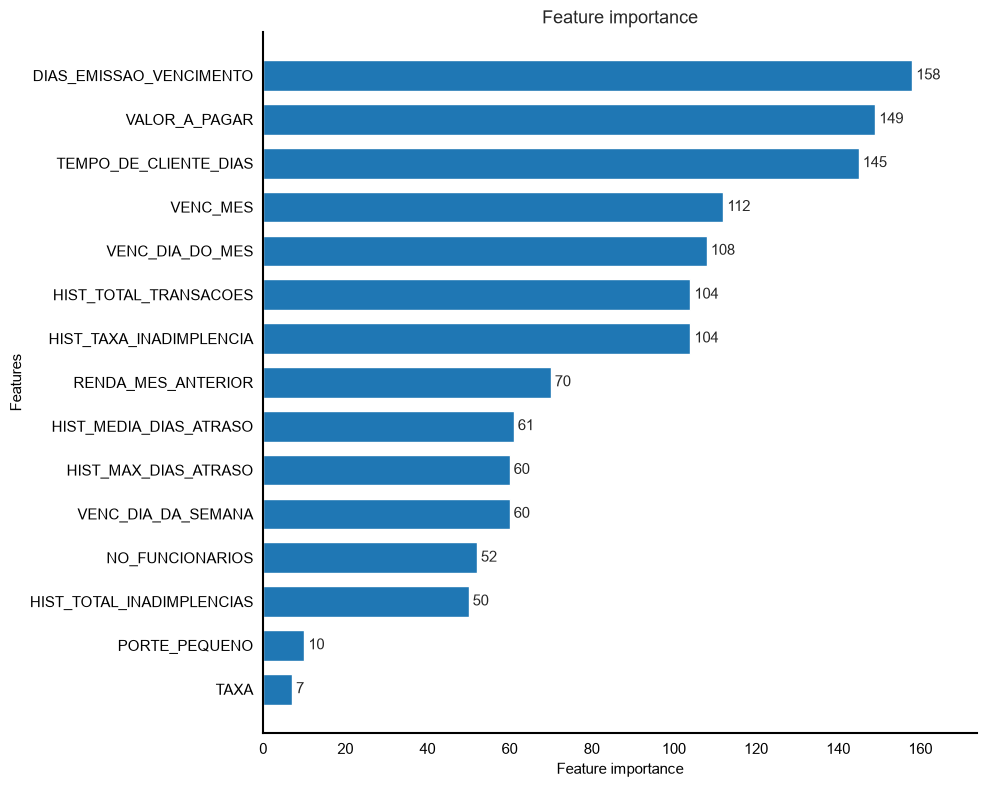

In [26]:

y_pred_proba_validacao = lgbm_model.predict_proba(X_validacao)[:, 1]

auc_score = roc_auc_score(y_validacao, y_pred_proba_validacao)
print(f"AUC na Validação: {auc_score:.4f}")


fpr, tpr, thresholds = roc_curve(y_validacao, y_pred_proba_validacao)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Referência Aleatória')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
#plt.title('Curva ROC - Conjunto de Validação')
plt.legend(loc="lower right")
plt.grid(False)
plt.show()


lgb.plot_importance(lgbm_model, max_num_features=15, figsize=(10, 8), height=0.7)
#plt.title('Features Mais Importantes')
plt.tight_layout()
plt.grid(False)
plt.show()

c:\Users\betim\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\betim\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


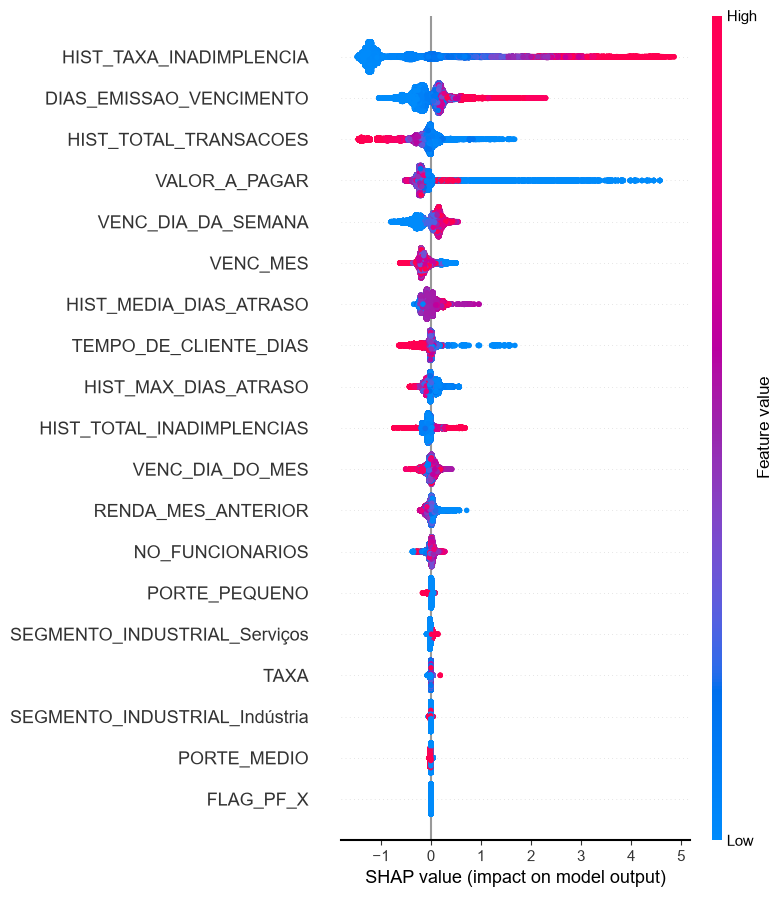

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Inicializar o explainer
explainer = shap.TreeExplainer(lgbm_model)

# 2. Calcular os SHAP values para o conjunto de validação
shap_values = explainer.shap_values(X_validacao)

# Se o retorno for uma lista de arrays (para classificação binária),
# selecionamos shap_values[1] (classe positiva). Se não for lista, usamos direto.
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

# 3. Gerar o gráfico formatado para as normas da Esalq
plt.figure(figsize=(10, 6))

# show=False permite aplicar as formatações adicionais
shap.summary_plot(values_to_plot, X_validacao, plot_type="dot", show=False)

# Limpeza e adequação estética (Normas Esalq)
plt.grid(False)
ax = plt.gca()
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_linewidth(1.5)
    ax.spines[s].set_color('black')

plt.title("") 
plt.tight_layout()
plt.show()

## 7.3. Benchmark com outros Modelos


### 7.3.1. RandomForest

In [29]:
resultados_benchmark = {'LightGBM': auc_score}


rf_model = RandomForestClassifier(n_estimators=200,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1,
                                  max_depth=20)

rf_model.fit(X_treino, y_treino)

y_pred_proba_rf = rf_model.predict_proba(X_validacao)[:, 1]
auc_score_rf = roc_auc_score(y_validacao, y_pred_proba_rf)
resultados_benchmark['RandomForest'] = auc_score_rf

print(f"AUC do RandomForest na Validação: {auc_score_rf:.4f}")

AUC do RandomForest na Validação: 0.9681


### 7.3.2. Regressão Logistica

In [30]:
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_validacao_scaled = scaler.transform(X_validacao)

lr_model = LogisticRegression(class_weight='balanced',
                              random_state=42,
                              solver='liblinear',
                              max_iter=1000)

lr_model.fit(X_treino_scaled, y_treino)

y_pred_proba_lr = lr_model.predict_proba(X_validacao_scaled)[:, 1]
auc_score_lr = roc_auc_score(y_validacao, y_pred_proba_lr)
resultados_benchmark['LogisticRegression'] = auc_score_lr

print(f"AUC da Regressão Logística na Validação: {auc_score_lr:.4f}")

AUC da Regressão Logística na Validação: 0.9386


### 7.3.3. Resultado do Benchmark

In [31]:
print("-"*35)
print("      Resultado do Benchmark")
print("-"*35)

df_benchmark = pd.DataFrame(list(resultados_benchmark.items()), columns=['Modelo', 'AUC'])
df_benchmark_sorted = df_benchmark.sort_values(by='AUC', ascending=False)

print(df_benchmark_sorted)
print("-"*35)

melhor_modelo = df_benchmark_sorted.iloc[0]
print(f"\nO modelo com melhor performance foi o {melhor_modelo['Modelo']} com uma AUC de {melhor_modelo['AUC']:.4f}.")

-----------------------------------
      Resultado do Benchmark
-----------------------------------
               Modelo       AUC
0            LightGBM  0.972061
1        RandomForest  0.968096
2  LogisticRegression  0.938552
-----------------------------------

O modelo com melhor performance foi o LightGBM com uma AUC de 0.9721.


# 8. Treinamento do Modelo Final e Geração das Previsões

## 8.1. Treino final
Treino final com o LightGBM usando o número ideal de árvores encontrado pelo early stopping.

In [ ]:
best_iteration = lgbm_model.best_iteration_

if best_iteration is None or best_iteration <= 0:
    print("Early stopping não foi ativado. Usando 100 estimadores como padrão.")
    best_iteration = 100
else:
    print(f"Usando o número otimizado de árvores para o treino final: {best_iteration}")

#scale_pos_weight para o dataset completo
contagem_total = y.value_counts()
escala_final = contagem_total[0] / contagem_total[1]

lgbm_final_model = lgb.LGBMClassifier(objective='binary',
                                      metric='auc',
                                      scale_pos_weight=escala_final,
                                      random_state=42,
                                      n_estimators=best_iteration)

lgbm_final_model.fit(X_encoded, y)


Usando o número otimizado de árvores para o treino final: 42
[LightGBM] [Info] Number of positive: 64402, number of negative: 529189
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2282
[LightGBM] [Info] Number of data points in the train set: 593591, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.108496 -> initscore=-2.106201
[LightGBM] [Info] Start training from score -2.106201


LGBMClassifier(metric='auc', n_estimators=42, objective='binary',
               random_state=42, scale_pos_weight=np.float64(8.216965311636285))

## 8.2. Previsão na Base Teste


In [ ]:
probabilidades_teste = lgbm_final_model.predict_proba(X_teste_final_encoded)[:, 1]

# Criando o DataFrame final
df_resultado = pd.DataFrame({
    'ID_CLIENTE': df_teste_final['ID_CLIENTE'],
    'SAFRA_REF': df_teste_final['SAFRA_REF'],
    'PROBABILIDADE_INADIMPLENCIA': probabilidades_teste
})

df_resultado.to_csv('resultado_treino.csv', index=False)

print("\nArquivo 'resultado_treino.csv' criado com sucesso!")
print("\nVisualização das 5 primeiras linhas do arquivo de submissão:")
print(df_resultado.head())


Arquivo 'resultado_treino.csv' criado com sucesso!

Visualização das 5 primeiras linhas do arquivo de submissão:
            ID_CLIENTE  SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
0  5058298901476893676 2021-07-01                     0.282856
1   274692171162531764 2021-07-01                     0.244747
2   274692171162531764 2021-07-01                     0.353004
3   274692171162531764 2021-07-01                     0.235184
4   465309249432033993 2021-07-01                     0.237277


# 9. Conclusão

Neste projeto foi abordado o desafio de prever a probabilidade de inadimplência de clientes com base em seu histórico de transações e dados cadastrais.
O processo foi estruturado em etapas claras, desde a análise dos dados até a avaliação de múltiplos modelos de machine learning.

#### Análise e Preparação dos Dados

 com uma análise exploratória detalhada para entender as características dos dados, identificando um desbalanceamento significativo na variável alvo (apenas 7% dos casos representando inadimplência).

A **Feature Engineering** foi uma etapa muito importante, onde foram criadas features de valor preditivo, como a taxa de inadimplência histórica (`HIST_TAXA_INADIMPLENCIA`) e o tempo de relacionamento do cliente (`TEMPO_DE_CLIENTE_DIAS`).

A validação visual dessas features já indicava um forte poder de separação entre as classes.

#### Estratégia de Validação e Benchmark de Modelos

Para garantir uma avaliação adequada e evitar *data leakage*, foi utilizada uma divisão temporal, treinando os modelos em dados mais antigos e validando-os nos dois meses mais recentes, o que simula um cenário de produção.

Foi realizado um benchmark comparando três algoritmos distintos para selecionar o mais performático:

* **1. Regressão Logística**: que obteve um score AUC de 0.9386.
* **2. Random Forest**: que obteve um score AUC de 0.9715.
* **3. LightGBM**: que atingiu o maior score AUC de 0.9721 na validação. O treinamento utilizou a técnica de *early stopping*, que otimizou o número de iterações para 42, evitando o *overfitting*.

Com base no benchmark, o **LightGBM** foi selecionado como o modelo final. A análise de importância das features revelou que, além do histórico do cliente, o contexto da cobrança (como o prazo de pagamento) é um fator extremamente relevante.

# 10. Referências Teóricas
***

* **Pandas Documentation.** https://pandas.pydata.org/docs/
* **Scikit-learn Documentation.** https://scikit-learn.org/stable/
* **LightGBM Python implementation.** https://github.com/Microsoft/LightGBM/tree/master/python-package
* **RandomForestClassifier (Scikit-learn).** http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* **ROC-AUC characteristic (Wikipedia).** https://en.wikipedia.org/wiki/Receiver_operating_characteristic#Area_under_the_curve
* **LogisticRegression (Scikit-learn).** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
* **Machine Learning para Avaliação de Risco de Crédito.** *Medium - Data Hackers*. https://medium.com/data-hackers/machine-learning-para-avalia%C3%A7%C3%A3o-de-risco-de-cr%C3%A9dito-49578b03b4b8
* **Dados Desbalanceados: O que são e como evitá-los.** *Medium - Turing Talks*. https://medium.com/turing-talks/dados-desbalanceados-o-que-s%C3%A3o-e-como-evit%C3%A1-los-43df4f49732b
* **Light GBM: Light and Powerful Gradient Boost Algorithm.** *Medium - Turkish Technology*. https://medium.com/@turkishtechnology/light-gbm-light-and-powerful-gradient-boost-algorithm-eaa1e804eca8
* **Credit Card Fraud Detection Predictive Models.** *Kaggle*. https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models#Conclusions
* **Timeseries Split with Sklearn Tips.** *Medium - Stan_DS*. https://medium.com/@Stan_DS/timeseries-split-with-sklearn-tips-8162c83612b9